# Stats

#### Compute metrics (ROC-AUC, PR-AUC, F1 and Precision)

In [ ]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, 
    auc as auc_pr, average_precision_score, f1_score
)

def calculate_all_metrics(df_data, numeric_cols):
    """
    Calculate comprehensive metrics for each predictor using domain knowledge from YAML.

    Uses get_direction() to determine metric direction from YAML file.
    
    Parameters:
    -----------
    df_data : DataFrame
        Data containing 'binder' column (target) and score columns
    numeric_cols : list
        List of metric column names to evaluate
    
    Returns:
    --------
    DataFrame with columns: metric, raw_roc, aligned_roc, pr_auc, f1, avg_precision, note
    """
    results = []
    
    for col in numeric_cols:
        # Skip if insufficient data
        if df_data[col].notna().sum() < 2 or df_data[col].nunique() < 2:
            continue
        
        try:
            # Clean data
            clean_data = df_data[[col, 'binder']].dropna()
            if clean_data['binder'].nunique() < 2:
                continue
            
            y_true = clean_data['binder'].astype(int)
            y_score_raw = clean_data[col].values
            

            # Step 1: Calculate Raw ROC-AUC
            raw_roc = roc_auc_score(y_true, y_score_raw)
            
            # Step 2: Get direction from YAML (domain knowledge)
            direction = get_direction(col)
            
            # Step 3: Align scores (Higher is always better)
            aligned_scores = y_score_raw * direction
            aligned_roc = max(raw_roc, 1 - raw_roc)
            
            # Step 4: Calculate PR-AUC (Average Precision)
            pr_auc = average_precision_score(y_true, aligned_scores)
            
            # Step 5: PR curve + optimal threshold from PR/F1
            precisions, recalls, thr = precision_recall_curve(y_true, aligned_scores)

            # thresholds correspond to precisions[:-1] and recalls[:-1]
            f1_scores = (
                2 * precisions[:-1] * recalls[:-1]
            ) / (
                precisions[:-1] + recalls[:-1] + 1e-8
            )

            best_idx = np.argmax(f1_scores)

            best_threshold = thr[best_idx]

            y_pred = (aligned_scores >= best_threshold).astype(int)
            max_f1 = f1_score(y_true, y_pred)

            precision = precisions[:-1][best_idx]
            recall = recalls[:-1][best_idx]
            
            
            results.append({
                'metric': col,
                'raw_roc': round(raw_roc, 4),
                'aligned_roc': round(aligned_roc, 4),
                'pr_auc': round(pr_auc, 4),
                'f1': round(max_f1, 4),
                'precision': round(precision, 4),
                'recall': round(recall, 4),
                'opt_threshold': thr[best_idx] * direction,
                'direction': direction,
            })
        except Exception as e:
            continue
    
    # Create df and sort by PR-AUC
    results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
    return results_df

In [ ]:
all_iteration_results = []

for i in range(6):
    # Slice the data for the current iteration
    iteration_subset = scores_df[scores_df['iteration'] == i]
    # run function on subsets
    res = calculate_all_metrics(iteration_subset, numeric_cols)
    
    # tag and store
    res['iteration'] = i
    all_iteration_results.append(res)

# Combine all 10 dfs
long_results = pd.concat(all_iteration_results).reset_index(drop=True)
long_results.to_csv(OUTPUT_DIR / 'rankings.csv', index=False)

print(long_results.shape[0])
print("="*100)
print("Metric Evaluation")
print("="*100)
print(long_results.head(20).to_string(index=False))
print("\nSaved to: rankings.csv")

408
Metric Evaluation
                     metric  raw_roc  aligned_roc  pr_auc     f1  precision  recall  opt_threshold  direction  iteration
                   cf_ipsae   0.7479       0.7479  0.6383 0.6429     0.5455  0.7826       0.686116          1          0
     chai_constrained_ipsae   0.5751       0.5751  0.5712 0.5301     0.3636  0.9778       0.144082          1          0
   chai_unconstrained_ipsae   0.6131       0.6131  0.5411 0.5380     0.3680  1.0000       0.005231          1          0
                  cf_iplddt   0.6940       0.6940  0.5165 0.6232     0.4624  0.9556      84.733914          1          0
     af3_pyros_binder_score   0.4513       0.5487  0.5163 0.5521     0.3846  0.9783     116.330000         -1          0
                 cf_pdockq2   0.6801       0.6801  0.5146 0.6087     0.5072  0.7609       0.675200          1          0
                 pred_ilddt   0.6184       0.6184  0.5074 0.5755     0.4301  0.8696       0.194208          1          0
          

In [ ]:
# Group by the metric name and calculate mean and std for the numeric columns
stats_df = long_results.groupby('metric').agg({
    'raw_roc': ['mean', 'std'],
    'aligned_roc': ['mean', 'std'],
    'pr_auc': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'direction': ['mean'],
    'opt_threshold': ['mean'],
})

# Flatten the multi-index columns
stats_df.columns = [f"{col[0]}_{col[1]}" for col in stats_df.columns]
stats_df = stats_df.reset_index()

# Sort by the average PR-AUC
stats_df = stats_df.sort_values('pr_auc_mean', ascending=False)
stats_df.head()

,metric,raw_roc_mean,raw_roc_std,aligned_roc_mean,aligned_roc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,direction_mean,opt_threshold_mean
39,cf_ipsae,0.751800,0.009492,0.751800,0.009492,0.656983,0.024725,0.643850,0.004291,0.546900,0.006217,0.782600,0.000000,1.0,0.686116
48,chai_constrained_ipsae,0.594150,0.012507,0.594150,0.012507,0.573517,0.017409,0.539383,0.006398,0.372450,0.006085,0.977800,0.000000,1.0,0.144082
10,af3_ptm,0.709417,0.012016,0.709417,0.012016,0.550350,0.038185,0.647033,0.002041,0.501000,0.002449,0.913000,0.000000,1.0,0.790000
38,cf_iplddt,0.701983,0.011689,0.701983,0.011689,0.547950,0.035058,0.623717,0.006302,0.472900,0.028726,0.925967,0.072587,1.0,85.929777
55,chai_unconstrained_ipsae,0.638833,0.017699,0.638833,0.017699,0.545733,0.027423,0.551367,0.011313,0.433183,0.042222,0.782583,0.121432,1.0,0.074862


In [ ]:
# Create a display-friendly column for PR-AUC (does it make sense?) 
stats_df['PR-AUC (Mean ± Std)'] = stats_df.apply(
    lambda row: f"{row['pr_auc_mean']:.3f} ± {row['pr_auc_std']:.3f}", axis=1
)

print("Top 15 Metrics with Variance:")
print(stats_df.head(15).to_string(index=False))

stats_df.to_csv(OUTPUT_DIR / 'rankings_with_variance.csv', index=False)

Top 15 Metrics with Variance:
                     metric  raw_roc_mean  raw_roc_std  aligned_roc_mean  aligned_roc_std  pr_auc_mean  pr_auc_std  f1_mean   f1_std  precision_mean  precision_std  recall_mean  recall_std  direction_mean  opt_threshold_mean PR-AUC (Mean ± Std)
                   cf_ipsae      0.751800     0.009492          0.751800         0.009492     0.656983    0.024725 0.643850 0.004291        0.546900       0.006217     0.782600    0.000000             1.0            0.686116       0.657 ± 0.025
     chai_constrained_ipsae      0.594150     0.012507          0.594150         0.012507     0.573517    0.017409 0.539383 0.006398        0.372450       0.006085     0.977800    0.000000             1.0            0.144082       0.574 ± 0.017
                    af3_ptm      0.709417     0.012016          0.709417         0.012016     0.550350    0.038185 0.647033 0.002041        0.501000       0.002449     0.913000    0.000000             1.0            0.790000       0.55

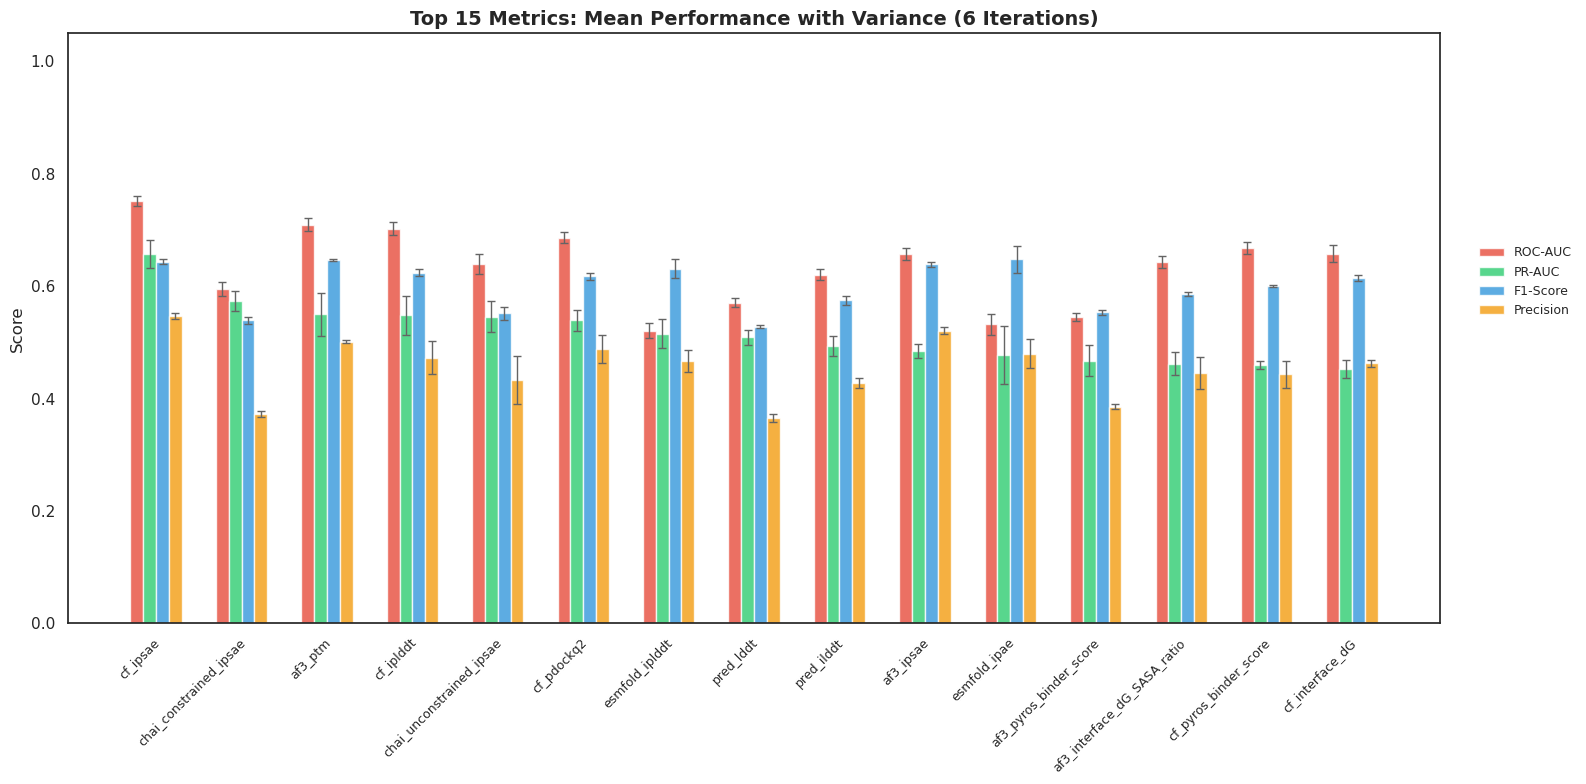

In [ ]:
import matplotlib.pyplot as plt

# top 15 based on the mean PR-AUC
top_15 = stats_df.head(15).copy()

fig, ax = plt.subplots(figsize=(16, 8))
x_pos = range(len(top_15))
width = 0.15

metrics_to_plot = [
    ('aligned_roc', 'ROC-AUC', '#e74c3c'),
    ('pr_auc', 'PR-AUC', '#2ecc71'),
    ('f1', 'F1-Score', '#3498db'),
    ('precision', 'Precision', '#f39c12'),
    #('recall', 'Recall', '#9b59b6')
]

# plot each metric with its error bars
for i, (col, label, color) in enumerate(metrics_to_plot):
    # Calculate offset for grouped bar
    offset = (i - 2) * width 
    
    ax.bar(
        [p + offset for p in x_pos], 
        top_15[f'{col}_mean'], 
        width, 
        yerr=top_15[f'{col}_std'], # var
        label=label, 
        color=color, 
        alpha=0.8,
        capsize=3,
        error_kw={'elinewidth': 1, 'ecolor': "#646464"}
    )

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Top 15 Metrics: Mean Performance with Variance (6 Iterations)', 
             fontsize=14, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(top_15['metric'], rotation=45, ha='right', fontsize=9)

# Place legend outside to the right
ax.legend(fontsize=9, loc='lower left', bbox_to_anchor=(1.02, 0.5), frameon=False)

ax.set_ylim([0, 1.05]) # room for error bars
ax.grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top15_metrics_variance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Visualizations

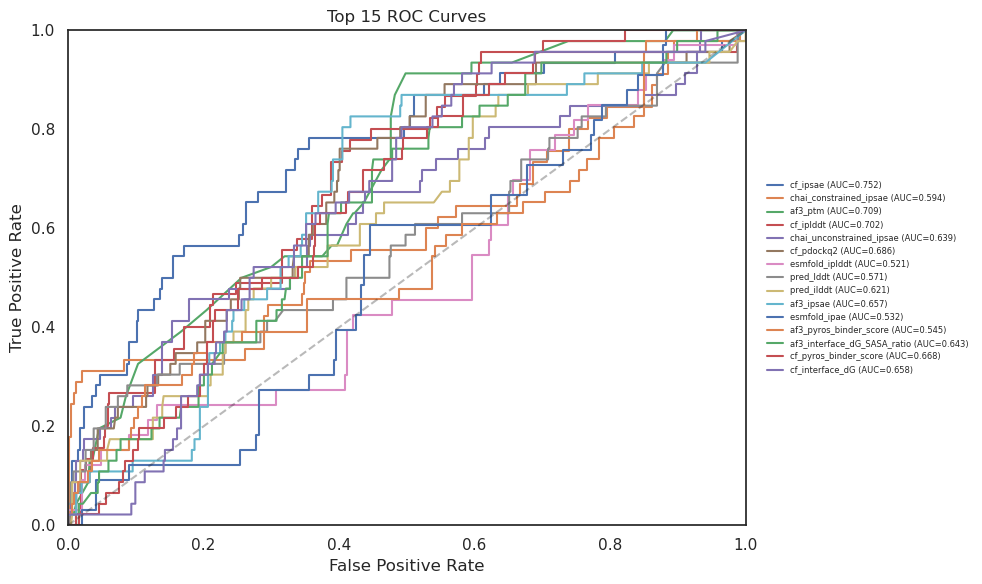

In [ ]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in top_15.iterrows():
    metric = row['metric']
    aligned_roc = row['aligned_roc_mean']
    direction = row['direction_mean']
    
    y_true = scores_df['binder'].values
    clean_idx = scores_df[metric].notna()
    
    y_score = scores_df.loc[clean_idx, metric].values * direction
    y_true_clean = y_true[clean_idx]
    
    fpr, tpr, _ = roc_curve(y_true_clean, y_score)
    
    ax.plot(fpr, tpr, linewidth=1.5, label=f'{metric} (AUC={aligned_roc:.3f})')

# diagonal reference
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Top 15 ROC Curves')

ax.legend(fontsize=6, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()

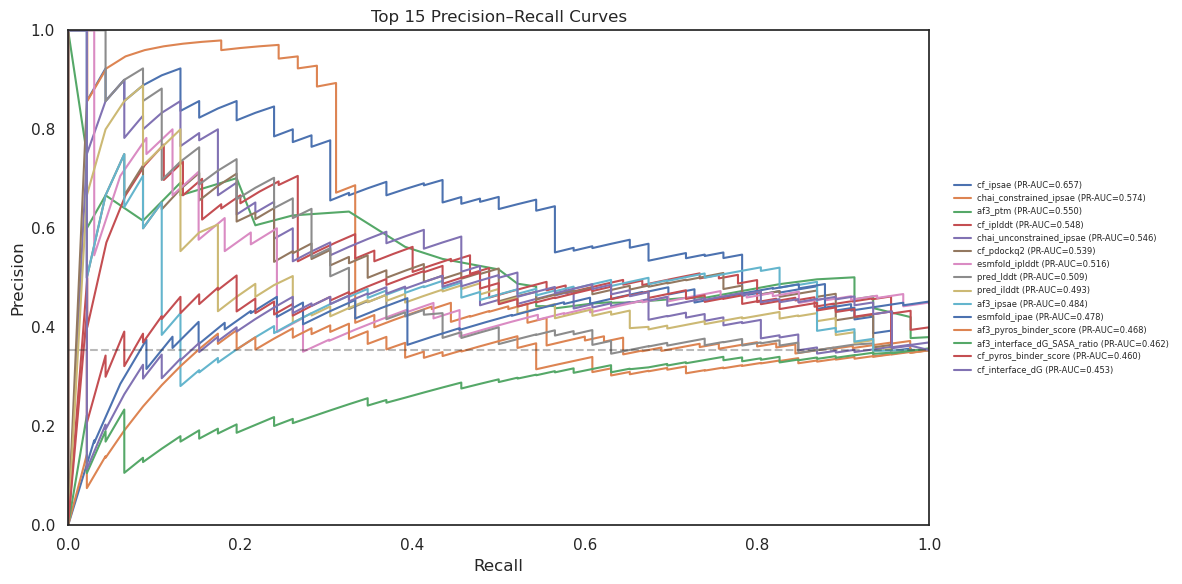

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))


for i, (_, row) in enumerate(top_15.iterrows()):
    metric = row['metric']
    pr_auc_value = row['pr_auc_mean']
    
    y_true = scores_df['binder'].values
    clean_idx = scores_df[metric].notna()
    
    y_score = scores_df.loc[clean_idx, metric].values
    y_true_clean = y_true[clean_idx]
    
    # skip invalid cases
    if len(np.unique(y_true_clean)) < 2:
        continue
    
    precision, recall, _ = precision_recall_curve(y_true_clean, y_score)

    
    ax.plot(recall, precision, label=f'{metric} (PR-AUC={pr_auc_value:.3f})')

# baseline (positive class prevalence)
baseline = y_true.mean()
ax.hlines(baseline, 0, 1, colors='k', linestyles='--', alpha=0.3)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Top 15 Precision–Recall Curves')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(False)


ax.legend(
    fontsize=6,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pr_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()


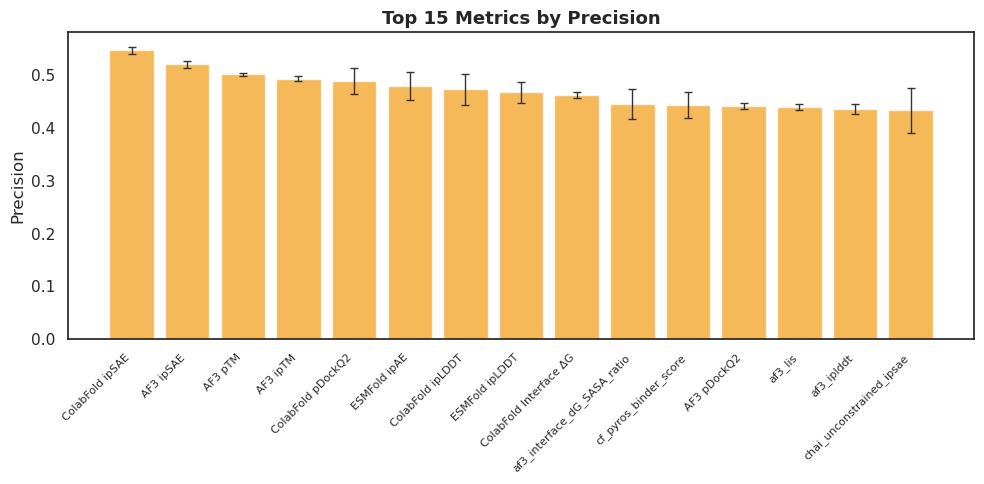

In [ ]:
# rearrange rankings by precision
sorted_precision = stats_df.sort_values(
    'precision_mean',
    ascending=False
)

# display labels
"""metric_label_map = {
    "chai_unconstrained_per_chain_iptm": "Chai-1 Interface pTM",
    "cf_ipsae": "ColabFold ipSAE",
    "cf_pdockq2": "ColabFold pDockQ2",
    "cf_iplddt": "ColabFold ipLDDT",
    "af3_ptm": "AF3 pTM",
    "cf_interface_dG": "ColabFold Interface ΔG",
    "af3_ipsae": "AF3 ipSAE",
    "af3_iptm": "AF3 ipTM",
    "esmfold_ipae": "ESMFold ipAE",
    "chai_unconstrained_per_chain_ptm": "Chai-1 pTM",
    "af3_pdockq2": "AF3 pDockQ2",
    "esmfold_iplddt": "ESMFold ipLDDT",
    "boltz_free_ipsae": "Boltz-2 ipSAE",
    "boltz_template_per_chain_pair_iptm": "Boltz-1 Interface pTM",
    "chai_unconstrained_ptm": "Chai-1 pTM",

}"""

# plot top15 precision
fig, ax = plt.subplots(figsize=(10, 5))

top_15_precision = sorted_precision.head(15)

x = np.arange(len(top_15_precision))

ax.bar(
    x,
    top_15_precision['precision_mean'],
    color='#f39c12',
    alpha=0.7,
    yerr=top_15_precision['precision_std'],
    capsize=3,
    error_kw={
        'elinewidth': 1,
        'ecolor': '#333333'
    }
)

ax.set_ylabel('Precision', fontsize=12)
ax.set_title(
    'Top 15 Metrics by Precision',
    fontsize=13,
    fontweight='bold'
)

# custom labels
display_labels = [
    metric_label_map.get(m, m)
    for m in top_15_precision['metric']
]

ax.set_xticks(range(len(top_15_precision)))

ax.set_xticklabels(
    display_labels,
    rotation=45,
    ha='right',
    fontsize=8
)

ax.grid(False)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / 'top15_precision.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

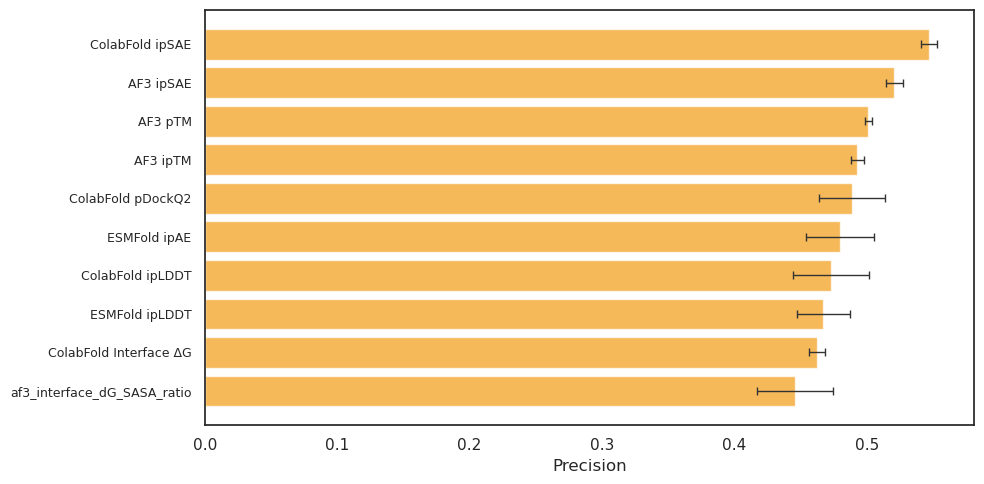

In [ ]:
# rearrange rankings by precision
sorted_precision = stats_df.sort_values(
    'precision_mean',
    ascending=False
)

# display labels
metric_label_map = {
    "chai_unconstrained_per_chain_iptm": "Chai-1 ipTM",
    "cf_ipsae": "ColabFold ipSAE",
    "cf_pdockq2": "ColabFold pDockQ2",
    "cf_iplddt": "ColabFold ipLDDT",
    "af3_ptm": "AlphaFold3 pTM",
    "cf_interface_dG": "ColabFold Interface ΔG",
    "af3_ipsae": "AlphaFold3 ipSAE",
    "af3_iptm": "AlphaFold3 ipTM",
    "esmfold_ipae": "ESMFold ipAE",
    "chai_unconstrained_per_chain_ptm": "Chai-1 pTM",
    "af3_pdockq2": "AlphaFold3 pDockQ2",
    "esmfold_iplddt": "ESMFold ipLDDT",
    "boltz_free_ipsae": "Boltz-2 ipSAE",
    "boltz_template_per_chain_pair_iptm": "Boltz-1 ipTM",
    "chai_unconstrained_ptm": "Chai-1 pTM",

}

# plot top15 precision
fig, ax = plt.subplots(figsize=(10, 5))

top_15_precision = sorted_precision.head(10)

# positions
y = np.arange(len(top_15_precision))

# custom labels
display_labels = [
    metric_label_map.get(m, m)
    for m in top_15_precision['metric']
]

# horizontal bars
ax.barh(
    y,
    top_15_precision['precision_mean'],
    color='#f39c12',
    alpha=0.7,
    xerr=top_15_precision['precision_std'],
    capsize=3,
    error_kw={
        'elinewidth': 1,
        'ecolor': '#333333'
    }
)

# y-axis labels
ax.set_yticks(y)
ax.set_yticklabels(display_labels, fontsize=9)

# labels/title
ax.set_xlabel('Precision', fontsize=12)
#ax.set_title('Top 15 Metrics by Precision',fontsize=13,fontweight='bold')

# highest score on top
ax.invert_yaxis()

ax.grid(False)

plt.tight_layout()

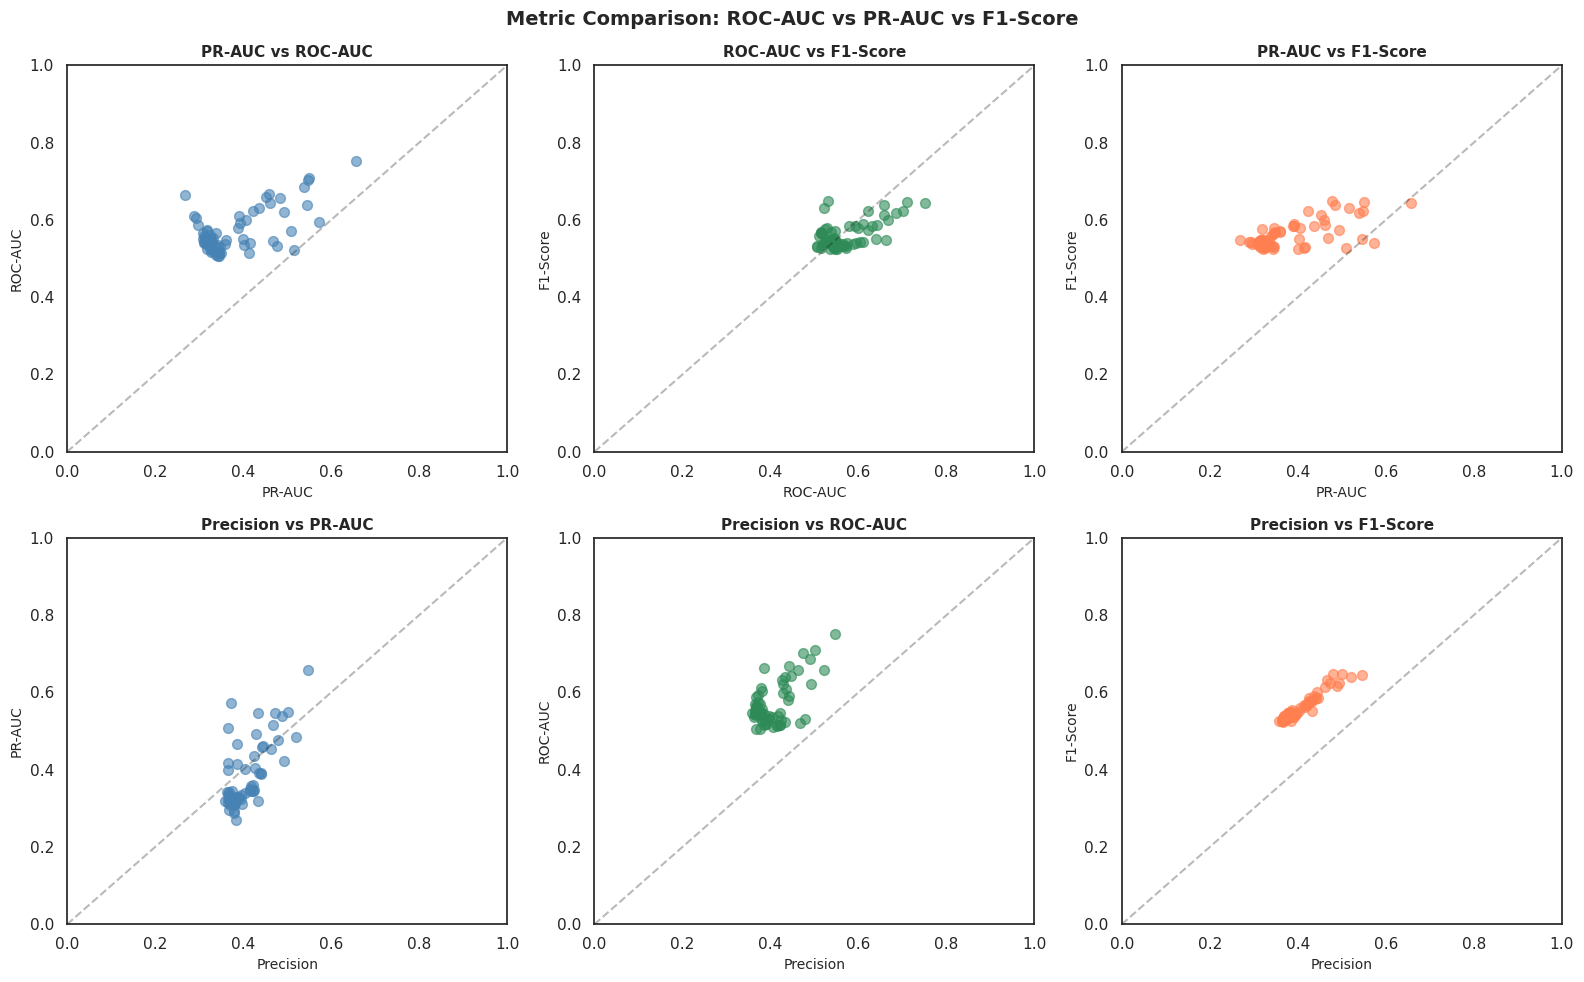

In [ ]:
## Compare All Metrics: ROC-AUC, PR-AUC, and F1
sorted_precision = stats_df.sort_values('precision_mean', ascending=False)
sorted_f1 = stats_df.sort_values('f1_mean', ascending=False)
sorted_auc = stats_df.sort_values('aligned_roc_mean', ascending=False)
sorted_pr_auc = stats_df.sort_values('pr_auc_mean', ascending=False)
sorted_recall = stats_df.sort_values('recall_mean', ascending=False)

# Create comprehensive comparison dataframes
comparision = pd.DataFrame({
    'ROC-AUC': sorted_auc['aligned_roc_mean'],
    'PR-AUC': sorted_pr_auc['pr_auc_mean'],
    'F1-Score': sorted_f1['f1_mean'],
    'Precision': sorted_precision['precision_mean'],
    'Recall': sorted_recall['recall_mean']
}).fillna(0).sort_values('PR-AUC', ascending=False)

#print(comparision.to_string())


# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ROC-AUC vs PR-AUC
ax = axes[0, 0]
ax.scatter(comparision['PR-AUC'], comparision['ROC-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('ROC-AUC', fontsize=10)
ax.set_title('PR-AUC vs ROC-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# ROC-AUC vs F1
ax = axes[0, 1]
ax.scatter(comparision['ROC-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('ROC-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# PR-AUC vs F1
ax = axes[0, 2]
ax.scatter(comparision['PR-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('PR-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vs PR-AUC
ax = axes[1, 0]
ax.scatter(comparision['Precision'], comparision['PR-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('Precision vs PR-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vsROC-AUC 
ax = axes[1, 1]
ax.scatter(comparision['Precision'], comparision['ROC-AUC'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('ROC-AUC', fontsize=10)
ax.set_title('Precision vs ROC-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vs F1
ax = axes[1, 2]
ax.scatter(comparision['Precision'], comparision['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('Precision vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])



plt.suptitle('Metric Comparison: ROC-AUC vs PR-AUC vs F1-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'metrics_comparison_combined.png', dpi=150, bbox_inches='tight')
plt.show()

#### Quadrant plots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

def plot_top_quadrant(scores_df, stats_df, label_points=False):
    # Get Top 2 by PR-AUC
    top_20 = stats_df.sort_values(by='pr_auc_mean', ascending=False).head(20)
    if len(top_20) < 2: return
    
    # Selecting by index
    m1_info, m2_info = top_20.iloc[0], top_20.iloc[2]
    
    m1, t1, d1 = m1_info['metric'], m1_info['opt_threshold_mean'], m1_info['direction_mean']
    m2, t2, d2 = m2_info['metric'], m2_info['opt_threshold_mean'], m2_info['direction_mean']

    # AGGREGATE: Instead of plotting every iteration, plot the MEAN of each sample
    plot_df = scores_df.groupby(['source', 'sample', 'type', 'binder'])[[m1, m2]].agg(['mean', 'std']).reset_index()
    
    # Flatten multi-index columns: 'metric_mean', 'metric_std'
    plot_df.columns = [f"{c[0]}_{c[1]}" if c[1] else c[0] for c in plot_df.columns]

    # Map alpha values directly into the dataframe
    alpha_dict = {"target_shuffle": 0.4, "original": 1.0, "alanine_scan": 1.0}
    plot_df["alpha"] = plot_df["type"].map(alpha_dict)

    plot_df.to_csv(OUTPUT_DIR / 'plot_df.csv', index=False) 

    fig, ax = plt.subplots(figsize=(8, 8))

# 2. DEFINE MAPPINGS
    colors_map = {'germinal': "#2ecc71", 'mcmahon': "#d6a439", 'snir_ab': "#1f3397"}
    marker_map = {0: 'X', 1: 'o'} # Check if your binder is 0/1 or True/False
    alpha_map = {"target_shuffle": 0.4, "original": 1.0, "alanine_scan": 1.0}

    # 3. PLOT (Turn legend OFF to prevent column names from appearing)
    for t, subdf in plot_df.groupby("type"):
        sns.scatterplot(
            data=subdf,
            x=f"{m1}_mean", y=f"{m2}_mean",
            hue='source', palette=colors_map,
            style='binder', markers=marker_map,
            s=100, alpha=alpha_map.get(t, 1.0),
            edgecolor='w', legend=False # <--- CRITICAL
        )

    ax.set_aspect("equal", adjustable="box")
    # 4. MANUAL AXIS LABELS (This fixes the "whole column name" issue)
    plt.xlabel(f"{m1}\n(PR-AUC: {m1_info['pr_auc_mean']:.3f})", fontsize=11)
    plt.ylabel(f"{m2}\n(PR-AUC: {m2_info['pr_auc_mean']:.3f})", fontsize=11)
    plt.title(f"Comparing Metrics: {m1} vs {m2}\n", fontsize=14, fontweight='bold')

    # 5. BUILD CUSTOM LEGEND
    legend_handles = []
    
    # Section: Source
    legend_handles.append(mpatches.Patch(color='none', label='SOURCE'))
    for label, color in colors_map.items():
        legend_handles.append(mlines.Line2D([], [], color=color, marker='s', linestyle='None', markersize=8, label=label))

    # Section: Binder
    #legend_handles.append(mpatches.Patch(color='none', label='BINDER'))
    #for val, marker in marker_map.items():
        #legend_handles.append(mlines.Line2D([], [], color='gray', marker=marker, linestyle='None', markersize=8, label=f"Binder: {val}"))

    # Section: Type
    #legend_handles.append(mpatches.Patch(color='none', label='TYPE'))
    #for label, alpha in alpha_map.items():
        #legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=8, alpha=alpha, label=label))

    # Thresholds (add to legend too if you like)
    t1_line = plt.axvline(t1, color='black', linestyle='--', alpha=0.3)
    t2_line = plt.axhline(t2, color='black', linestyle='--', alpha=0.3)
    #legend_handles.extend([t1_line, t2_line])

    plt.legend(handles=legend_handles, fontsize=9, loc='lower center', bbox_to_anchor=(1.22, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

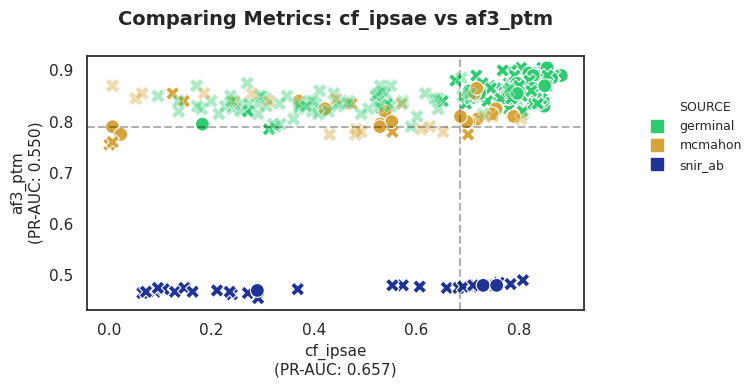

In [ ]:
plot_top_quadrant(scores_df, stats_df)

In [ ]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def plot_top_quadrant(scores_df, stats_df, label_points=False):
    # Get Top 2 by PR-AUC
    top_20 = stats_df.sort_values(by="pr_auc_mean", ascending=False).head(20)
    if len(top_20) < 2:
        return

    # Selecting by index
    m1_info, m2_info = top_20.iloc[0], top_20.iloc[1]

    m1, t1, d1 = (
        m1_info["metric"],
        m1_info["opt_threshold_mean"],
        m1_info["direction_mean"],
    )
    m2, t2, d2 = (
        m2_info["metric"],
        m2_info["opt_threshold_mean"],
        m2_info["direction_mean"],
    )

    # AGGREGATE
    plot_df = (
        scores_df.groupby(["source", "sample", "type", "binder"])[[m1, m2]]
        .agg(["mean", "std"])
        .reset_index()
    )
    plot_df.columns = [
        f"{c[0]}_{c[1]}" if c[1] else c[0] for c in plot_df.columns
    ]

    # --- LAYOUT FIX 1: Increase width to accommodate the external legend ---
    fig, ax = plt.subplots(figsize=(8, 8))

    # MAPPINGS
    colors_map = {
        "germinal": "#2ecc71",
        "mcmahon": "#d6a439",
        "snir_ab": "#1f3397",
    }
    marker_map = {0: "X", 1: "o"}
    alpha_map = {"target_shuffle": 0.4, "original": 1.0, "alanine_scan": 1.0}

    # PLOT
    for t, subdf in plot_df.groupby("type"):
        sns.scatterplot(
            data=subdf,
            x=f"{m1}_mean",
            y=f"{m2}_mean",
            hue="source",
            palette=colors_map,
            style="binder",
            markers=marker_map,
            s=80,  # Slightly scaled down for visual clarity
            alpha=alpha_map.get(t, 1.0),
            edgecolor="w",
            linewidth=0.6,
            legend=False,
            ax=ax,
        )

    # --- LAYOUT FIX 2: Explicitly force 1:1 data aspect ratio inside the box ---
    ax.set_aspect("equal", adjustable="box")

    # Threshold lines
    ax.axvline(t1, color="black", linestyle="--", alpha=0.3, zorder=1)
    ax.axhline(t2, color="black", linestyle="--", alpha=0.3, zorder=1)

    # Dynamic limits so points aren't cut off at the edges
    all_x = plot_df[f"{m1}_mean"]
    all_y = plot_df[f"{m2}_mean"]
    min_val = min(all_x.min(), all_y.min()) * 0.9
    max_val = max(all_x.max(), all_y.max()) * 1.05
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)

    # AXIS LABELS (Added padding)
    ax.set_xlabel(
        f"{m1}\n(PR-AUC: {m1_info['pr_auc_mean']:.3f})",
        fontsize=11,
        labelpad=10,
    )
    ax.set_ylabel(
        f"{m2}\n(PR-AUC: {m2_info['pr_auc_mean']:.3f})",
        fontsize=11,
        labelpad=10,
    )

    legend_name_map = {
    "germinal": "Germinal",
    "mcmahon": "McMahon",
    "snir_ab": "Snir"
}

    # --- LAYOUT FIX 3: Figure level title with padding to stop label overlaps ---
    #fig.suptitle( f"Comparing Metrics: {m1} vs {m2}", fontsize=13, fontweight="bold")
    legend_handles = []
    legend_handles.append(mpatches.Patch(color='none', label='Source'))
    for label, color in colors_map.items():
        legend_handles.append(
            mlines.Line2D(
                [],
                [],
                color=color,
                marker="s",
                linestyle="None",
                markersize=8,
                label=legend_name_map.get(label, label),  # <- rename here
            )
        )

    # --- LAYOUT FIX 4: Moved legend anchor point and cleaned styling ---
    ax.legend(
        handles=legend_handles,
        fontsize=9,
        loc="upper left",
        bbox_to_anchor=(1.05, 0.7),
        frameon=False,
        title_fontproperties={"weight": "bold"},
    )

    # --- LAYOUT FIX 5: Clean padding boundaries manually ---
    plt.tight_layout()
    fig.subplots_adjust(
        top=0.90, right=0.78
    )  # Locks down specific room on the right for the legend
    plt.show()

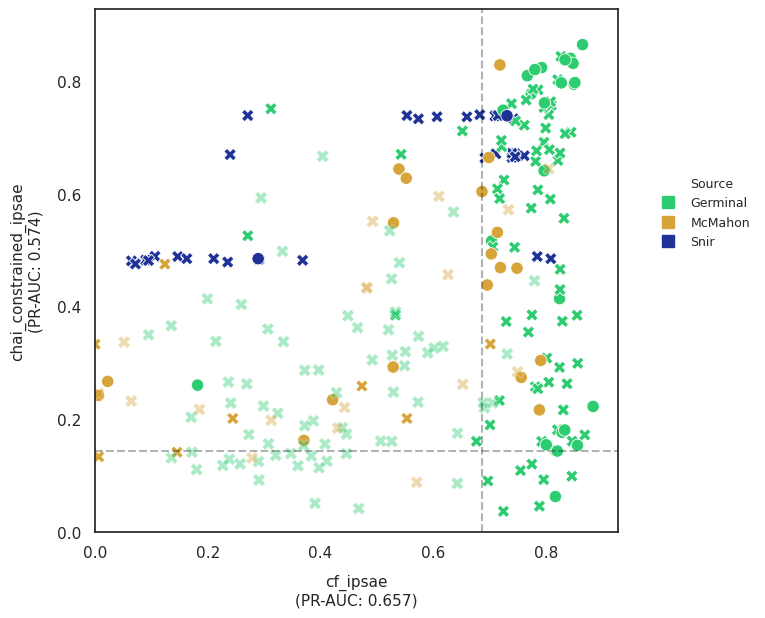

In [ ]:
plot_top_quadrant(scores_df, stats_df)

In [ ]:
import plotly.graph_objects as go


top_20 = stats_df.sort_values(by='pr_auc_mean', ascending=False).head(20)

m1_info, m2_info = top_20.iloc[0], top_20.iloc[2]

m1, t1, d1 = m1_info['metric'], m1_info['opt_threshold_mean'], m1_info['direction_mean']
m2, t2, d2 = m2_info['metric'], m2_info['opt_threshold_mean'], m2_info['direction_mean']

plot_df = (
    scores_df
    .groupby(['source', 'sample', 'type', 'binder'])[[m1, m2]]
    .agg(['mean', 'std'])
    .reset_index()
)

plot_df.columns = [
    f"{c[0]}_{c[1]}" if c[1] else c[0]
    for c in plot_df.columns
]


colors_map = {
    'germinal': "#2ecc71",
    'mcmahon': "#d6a439",
    'snir_ab': "#1f3397"
}

marker_map = {
    0: 'x',
    1: 'circle'
}



alpha_map = {
    "target_shuffle": 0.4,
    "original": 1.0,
    "alanine_scan": 1.0
}

# figure setup

fig = go.Figure()

# loop by type so opacity is consistent
for t, type_df in plot_df.groupby("type"):

    opacity = alpha_map.get(t, 1.0)

    # then split by source + binder
    for (source, binder), subdf in type_df.groupby(["source", "binder"]):

        fig.add_trace(
            go.Scatter(
                x=subdf[f"{m1}_mean"],
                y=subdf[f"{m2}_mean"],

                mode='markers',
                
                marker=dict(
                    color=colors_map[source],
                    symbol=marker_map[binder],
                    size=8,
                    opacity=opacity,
                    line=dict(width=0)
                ),

                name=f"{source} | {t} | binder={binder}",

                text=subdf["sample"],

                hovertemplate=(
                    "<b>%{text}</b><br>"
                    f"{m1}: %{{x:.3f}}<br>"
                    f"{m2}: %{{y:.3f}}<br>"
                    f"source: {source}<br>"
                    f"type: {t}<br>"
                    f"binder: {binder}<br>"
                    "<extra></extra>"
                ),

                showlegend=True
            )
        )


# Threshold lines
fig.add_vline(
    x=t1,
    line_dash="dash",
    line_color="black",
    opacity=0.3
)

fig.add_hline(
    y=t2,
    line_dash="dash",
    line_color="black",
    opacity=0.3
)


# Layout
fig.update_layout(
    width=900,
    height=700,
    plot_bgcolor='white',
    title=f"Comparing Metrics: {m1} vs {m2}",
    xaxis_title=f"{m1}<br>(PR-AUC: {m1_info['pr_auc_mean']:.3f})",
    yaxis_title=f"{m2}<br>(PR-AUC: {m2_info['pr_auc_mean']:.3f})",
    legend_title="Source / Type / Binder"
)

fig.show()

In [ ]:
top_20 = stats_df.sort_values(by='pr_auc_mean', ascending=False).head(20)


print(top_20["metric"].tolist())

['chai_constrained_per_chain_iptm', 'chai_unconstrained_per_chain_iptm', 'chai_constrained_ipsae', 'cf_ipsae', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_ipsae', 'af3_ipsae', 'cf_iplddt', 'chai_unconstrained_per_chain_ptm', 'cf_pdockq2', 'pred_ilddt', 'cf_pyros_binder_score', 'esmfold_iplddt', 'af3_ptm', 'cf_interface_dG', 'pred_lddt', 'af3_iptm', 'af3_interface_dG_SASA_ratio', 'esmfold_ipae', 'cf_interface_dG_SASA_ratio']


In [ ]:
scores_df.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm,iteration,binder_type
0,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-609,6.376025,88.098892,14.46,1.51,...,0.821457,0.3654,0.9208,0.4745,0.886037,0.897680,0.171786,0.758631,0,Binder
1,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-601,6.893648,87.943351,19.06,1.99,...,0.105424,0.3059,0.0374,0.0189,0.878948,0.880200,0.147295,0.598787,0,Binder
2,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_25-609,13.189712,84.282269,154.23,10.06,...,0.819429,0.5921,0.7323,0.5462,0.877172,0.878092,0.255400,0.682429,0,Binder
3,mcmahon,original,1,2.300000e-06,NaN,Nb.AQ100_Adiponectin,12.931578,81.319338,205.51,11.33,...,0.268686,0.2883,0.0783,0.2570,0.882637,0.875993,0.159133,0.256621,0,Binder
4,mcmahon,original,0,NaN,NaN,Nb.AQ101_Adiponectin,13.803496,80.758365,46.76,3.01,...,0.212057,0.1630,0.0450,0.1986,0.881152,0.878127,0.171685,0.326672,0,Non-Binder


In [ ]:
top20 = scores_df[['source','type','binder','KD[M]','EC50[M]','sample', 'iteration', 'chai_constrained_per_chain_iptm', 'chai_unconstrained_per_chain_iptm', 'chai_constrained_ipsae', 'cf_ipsae', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_ipsae', 'af3_ipsae', 'cf_iplddt', 'chai_unconstrained_per_chain_ptm', 'cf_pdockq2', 'pred_ilddt', 'cf_pyros_binder_score', 'esmfold_iplddt', 'af3_ptm', 'cf_interface_dG', 'pred_lddt', 'af3_iptm', 'af3_interface_dG_SASA_ratio', 'esmfold_ipae', 'cf_interface_dG_SASA_ratio']]
top20 = top20.to_csv("/home/bri/pymol/EDA/static/scores2combine.csv", index=False)
